In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:

def kernel_v1(sig, dx, dsig):
    sigma = float(sig) * dsig
    M = int(10. * sig + 0.5)
    x = np.arange(-M, M+1, dtype=np.float64)*dx
    return np.exp(-x**2 / (2. * sigma**2))/np.sqrt(2. * np.pi * sigma**2)

def kernel_v2(sig, dx, dsig):
    sigma = float(sig) * dsig
    M = int(10. * sig + 0.5)
    x = np.arange(-M, M+1, dtype=np.float64)
    kernel = np.exp(-0.5 * (x/sigma)**2)
    kernel = kernel / np.nansum(kernel)
    return kernel


True


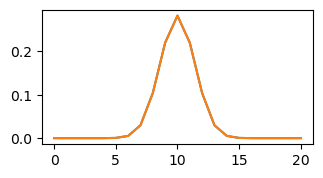

In [38]:
sig = 1
dx = 1.
dsig = np.sqrt(2.)
v1 = kernel_v1(sig, dx, dsig)
v2 = kernel_v2(sig, dx, dsig)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75))
ax.plot(v1)
ax.plot(v2)
print(np.allclose(v1, v2))

In [39]:
def kernel_v3(discrete_scale: np.floating) -> np.ndarray:
    radius = int(10.*discrete_scale + 0.5)
    x = np.arange(-radius, radius+1, dtype=np.float64)
    kernel = np.exp(-0.5 * (x/discrete_scale)**2)
    return kernel / np.sum(kernel)

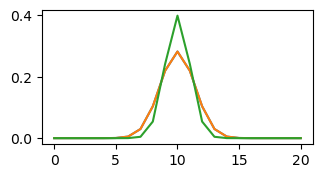

In [40]:
sig = 1.
v1 = kernel_v1(sig, dx, dsig)
v2 = kernel_v2(sig, dx, dsig)
v3 = kernel_v3(sig)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75))
ax.plot(v1)
ax.plot(v2)
ax.plot(v3)